# Injection Molding Defect Prediction - Modeling

In the EDA notebook I explored the data and found the parameters do separate good from scrap parts. Now I build models that actually predict good vs scrap from the 13 process parameters.

My plan, in order:

1. Prepare the data: split into train and test, and scale it.
2. Check whether the two classes can be split by a simple straight line (linear separability). This decides whether I need advanced models at all.
3. Build a Logistic Regression baseline (the simple model), then stronger models: a Support Vector Machine with a curved boundary, and XGBoost.
4. Explain the best model with SHAP, so I can point to the exact setting that caused a part to be scrap.
5. Add anomaly detection (Isolation Forest) to catch unusual cycles even without a label.

The point of step 2 is the logic of the whole notebook: if a straight line is not enough to separate good from scrap, that is the reason I move to the more advanced models, rather than using them just because they sound impressive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load and prepare the data

I load the raw file, rename the columns to the plain names from the EDA notebook, and rebuild the good vs scrap label. Scrap is the waste grade (quality 1), good is everything that passed (quality 2, 3, 4).

In [2]:
df = pd.read_csv('../data/raw/injection_molding.csv', sep=';')
rename = {
    'Melt temperature': 'melt_temp',
    'Mold temperature': 'mold_temp',
    'time_to_fill': 'fill_time',
    'ZDx - Plasticizing time': 'plasticizing_time',
    'ZUx - Cycle time': 'cycle_time',
    'SKx - Closing force': 'closing_force',
    'SKs - Clamping force peak value': 'clamping_force',
    'Ms - Torque peak value current cycle': 'torque_peak',
    'Mm - Torque mean value current cycle': 'torque_mean',
    'APSs - Specific back pressure peak value': 'back_pressure',
    'APVs - Specific injection pressure peak value': 'injection_pressure',
    'CPn - Screw position at the end of hold pressure': 'screw_position',
    'SVo - Shot volume': 'shot_volume',
}
df = df.rename(columns=rename)
features = list(rename.values())

df['quality'] = df['quality'].astype(int)
df['is_scrap'] = (df['quality'] == 1).astype(int)

X = df[features]
y = df['is_scrap']
print('X shape:', X.shape)
print('Scrap rate:', round(y.mean() * 100, 1), '%')

X shape: (1451, 13)
Scrap rate: 25.5 %


## 2. Train/test split and scaling

I split the data 80/20 into a training set (used to fit the models) and a test set (kept aside to judge them honestly on data they never saw). I use `stratify=y` so the scrap rate is the same in both halves.

Then I scale the features with StandardScaler. Scaling puts every parameter on the same footing (mean 0, similar spread) so that the big-number columns like the forces do not drown out the small ones. I fit the scaler on the training data only, then apply it to both, so no information from the test set leaks into training.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape[0], 'cycles')
print('Test: ', X_test.shape[0], 'cycles')
print('Train scrap rate:', round(y_train.mean() * 100, 1), '%')
print('Test scrap rate: ', round(y_test.mean() * 100, 1), '%')

Train: 1160 cycles
Test:  291 cycles
Train scrap rate: 25.5 %
Test scrap rate:  25.4 %


## 3. Are good and scrap linearly separable?

Before picking a model I ask a basic question: can I split good from scrap with a single straight line? If yes, a simple linear model is enough and there is no reason to reach for anything fancier. If no, that is the justification for the advanced models.

I check it two ways.

**First, by eye.** The data has 13 columns, and I cannot draw a 13 dimensional chart. So I use PCA, which squashes the 13 columns down to just 2 summary columns that keep as much of the spread as possible. That lets me draw every cycle as one dot on a 2D chart, colored by good or scrap. If the two colors sit in clean separate regions that a straight line could divide, the classes are close to linearly separable.

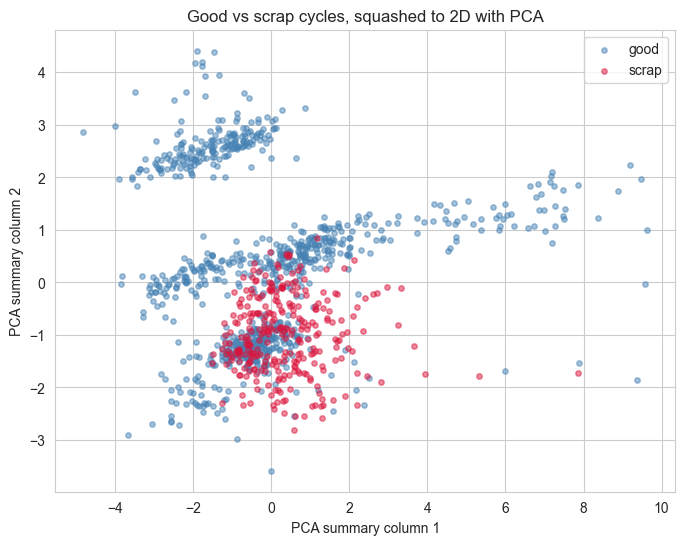

Spread kept by the 2 summary columns: 49.7 %


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
for label, name, color in [(0, 'good', 'steelblue'), (1, 'scrap', 'crimson')]:
    mask = y_train.values == label
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                s=15, alpha=0.5, label=name, color=color)
plt.xlabel('PCA summary column 1')
plt.ylabel('PCA summary column 2')
plt.title('Good vs scrap cycles, squashed to 2D with PCA')
plt.legend()
plt.show()

print('Spread kept by the 2 summary columns:',
      round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

**Second, by model.** Eyeballing a 2D squash can be misleading, so I confirm it with two models on the full 13 columns:

- a Support Vector Machine with a **straight line** boundary (`kernel='linear'`)
- a Support Vector Machine with a **curved** boundary (`kernel='rbf'`)

If the straight line model already does almost as well as the curved one, the classes are basically linearly separable. If the curved model clearly beats the straight line, they are not, and that is the reason to use models that can draw curved boundaries.

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score

# same settings I use in the model comparison later, so the numbers line up
lin = SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE)
lin.fit(X_train_scaled, y_train)
lin_pred = lin.predict(X_test_scaled)

rbf = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
rbf.fit(X_train_scaled, y_train)
rbf_pred = rbf.predict(X_test_scaled)

print('Straight line SVM : accuracy', round(accuracy_score(y_test, lin_pred), 3),
      '| scrap F1', round(f1_score(y_test, lin_pred), 3))
print('Curved SVM        : accuracy', round(accuracy_score(y_test, rbf_pred), 3),
      '| scrap F1', round(f1_score(y_test, rbf_pred), 3))

Straight line SVM : accuracy 0.852 | scrap F1 0.736
Curved SVM        : accuracy 0.918 | scrap F1 0.846


Both checks agree: the classes are **not** cleanly separable by a straight line.

In the PCA picture the good and scrap dots sit in overlapping clouds rather than two clean blocks, so no single straight line would split them. The models confirm it. The straight line SVM gets a scrap F1 of about 0.74, while the curved SVM jumps to about 0.85 (and accuracy from 0.85 to 0.92). That gap means a curved boundary captures something a straight line cannot.

This is the justification for the rest of the notebook: because a simple linear boundary is not enough, it makes sense to use models that can draw curved, flexible boundaries, namely the curved SVM and XGBoost. I am not using them because they sound advanced, I am using them because the data needs them.

(One note on the PCA picture: the 2 summary columns keep only about 50% of the spread of the original 13 columns, so the chart is a rough flattened view. The model based check on the full 13 columns is the more reliable test, and it agrees.)

## 4. Building the models

Now I train three models and compare them:

1. **Logistic Regression** - the simple baseline. It can only draw a straight line boundary, which I already showed is not enough. I keep it as the thing to beat.
2. **Support Vector Machine (curved)** - can draw a curved boundary.
3. **XGBoost** - a strong tree based model that builds many small decision trees and combines them.

Because scrap is the rarer class (about 25%), I tell each model to pay extra attention to it (`class_weight='balanced'` for the first two, `scale_pos_weight` for XGBoost). Otherwise a lazy model could score well just by calling almost everything good.

I judge the models on the **scrap** class specifically, using:

- **precision** - of the parts it flagged as scrap, how many really were scrap (few false alarms)
- **recall** - of the real scrap parts, how many it caught (few missed defects)
- **F1** - a single balance of precision and recall

Recall matters most here: a missed defective part is worse than a false alarm.

In [6]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score

# scrap is the rarer class, so weight it up
scrap_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'SVM (curved)': SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(scale_pos_weight=scrap_weight, eval_metric='logloss',
                             random_state=RANDOM_STATE),
}

results = []
predictions = {}
for name, model in models.items():
    # tree models do not need scaling; the other two do
    if name == 'XGBoost':
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    predictions[name] = pred
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'scrap_precision': precision_score(y_test, pred),
        'scrap_recall': recall_score(y_test, pred),
        'scrap_f1': f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).set_index('model').round(3)
results_df

,accuracy,scrap_precision,scrap_recall,scrap_f1
model,,,,
Logistic Regression,0.832,0.629,0.824,0.713
SVM (curved),0.918,0.805,0.892,0.846
XGBoost,0.983,0.973,0.959,0.966


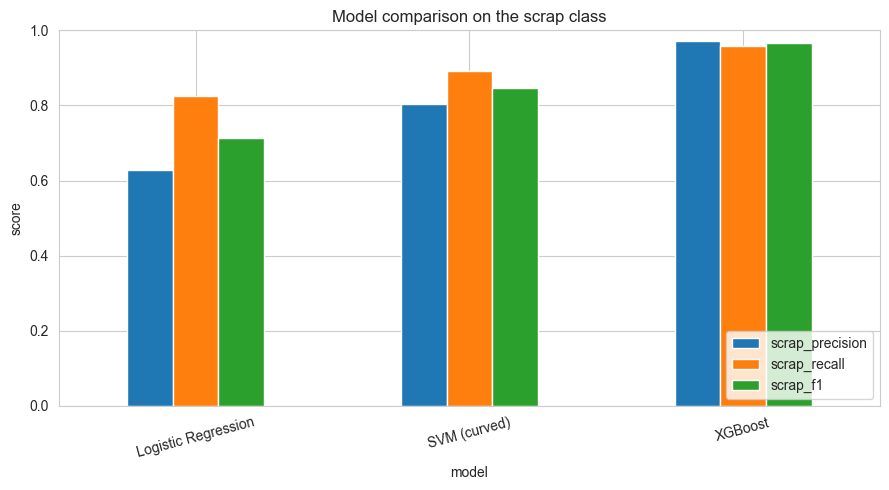

In [7]:
plt.figure(figsize=(9, 5))
results_df[['scrap_precision', 'scrap_recall', 'scrap_f1']].plot(
    kind='bar', ax=plt.gca())
plt.title('Model comparison on the scrap class')
plt.ylabel('score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

The results match what the separability check predicted. The straight line Logistic Regression is the weakest, with a scrap F1 of about 0.71. Moving to a curved boundary (SVM) lifts it to about 0.85, and XGBoost is best by a clear margin at about 0.97, catching almost all the scrap with very few false alarms. So the advanced models were worth it: the simple linear baseline leaves a lot on the table.

XGBoost is my chosen model. Now I look at its mistakes in detail with a confusion matrix. It shows four numbers: good parts called good, good called scrap (false alarms), scrap called good (missed defects), and scrap called scrap (caught).

Best model on scrap F1: XGBoost

              precision    recall  f1-score   support

        good       0.99      0.99      0.99       217
       scrap       0.97      0.96      0.97        74

    accuracy                           0.98       291
   macro avg       0.98      0.98      0.98       291
weighted avg       0.98      0.98      0.98       291



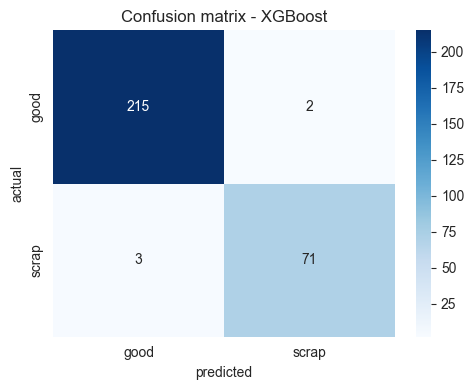

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

best_name = results_df['scrap_f1'].idxmax()
best_pred = predictions[best_name]
print('Best model on scrap F1:', best_name)
print()
print(classification_report(y_test, best_pred, target_names=['good', 'scrap']))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['good', 'scrap'], yticklabels=['good', 'scrap'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title(f'Confusion matrix - {best_name}')
plt.tight_layout()
plt.show()

On the 291 test parts, XGBoost gets scrap precision 0.97 and recall 0.96. Out of 74 real scrap parts it catches about 71 and misses only around 3, with only a couple of good parts wrongly flagged. For a defect catcher, missing very few scrap parts is exactly what I want.

## 5. Explaining the model with SHAP

A good score is not enough on a factory floor. An operator needs to know **why** a part was flagged as scrap and which setting to correct. SHAP answers that. For any prediction it splits the result into a contribution from each parameter: which settings pushed the part toward scrap and which pushed it toward good.

I run SHAP on the XGBoost model because it has a fast, exact explainer for tree models. The summary plot below ranks the parameters by how much they drive the predictions overall.

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


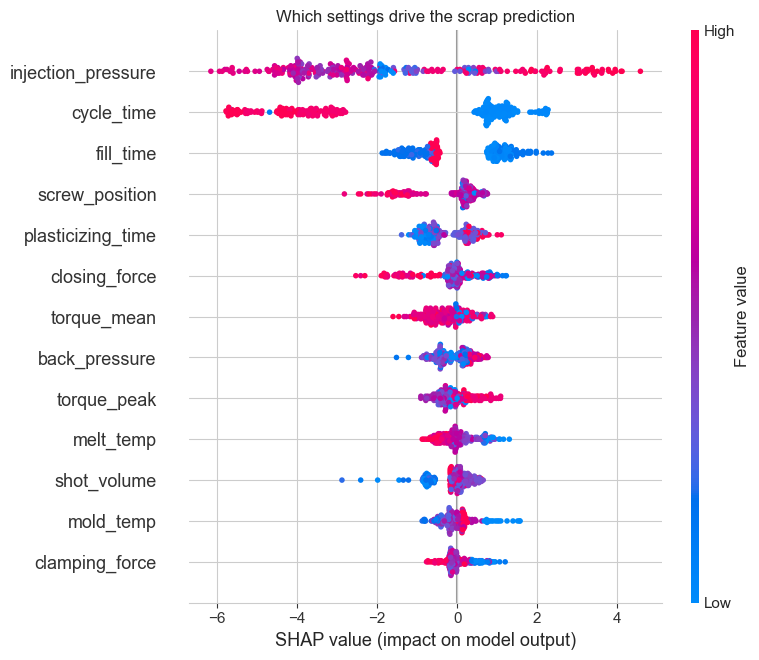

In [9]:
import shap

xgb_model = models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.title('Which settings drive the scrap prediction')
plt.tight_layout()
plt.show()

I also show a single prediction broken down, so you can see SHAP explain one specific part the way an operator would see it: this part was flagged, and here are the settings that caused it.

In [10]:
# pick one part the model predicted as scrap and explain it
scrap_idx = np.where(xgb_model.predict(X_test) == 1)[0][0]
row = X_test.iloc[scrap_idx]

contrib = pd.DataFrame({
    'setting': features,
    'value': row.values,
    'push_toward_scrap': shap_values[scrap_idx],
}).sort_values('push_toward_scrap', key=abs, ascending=False)

print('Explaining one part the model flagged as scrap:')
print('(positive push = made it look more like scrap)\n')
print(contrib.head(6).to_string(index=False))

Explaining one part the model flagged as scrap:
(positive push = made it look more like scrap)

           setting   value  push_toward_scrap
         fill_time   6.968          -1.394615
       torque_peak 120.500           1.083225
        cycle_time  74.820           0.917746
         melt_temp 106.478          -0.767645
    screw_position   8.800           0.485412
injection_pressure 917.500          -0.396715


In the single part above, the model flagged it as scrap and SHAP shows why: settings like torque peak and cycle time pushed it toward scrap, while fill time and melt temperature pushed the other way, but not enough to save it. This is the actionable part for a factory: instead of just a scrap flag, the operator sees which few settings drove it and where to look first.

## 6. Anomaly detection (catching defects without labels)

Everything so far needs labeled examples of scrap to learn from. But a real factory often does not have labels, or hits a brand new kind of fault it has never seen. For that I use **Isolation Forest**, an unsupervised model that learns what a normal cycle looks like and flags cycles that stand out, without ever being told which parts are scrap.

I fit it on the parameters alone (no label), ask it to flag roughly the same fraction as the real scrap rate, then check how often the cycles it flags really are scrap. This is not meant to beat the supervised model, it is a safety net for the no label case.

In [11]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=float(y.mean()), random_state=RANDOM_STATE)
iso.fit(X_train_scaled)

# -1 = flagged as anomaly, 1 = normal -> turn into 1 = flagged
flagged = (iso.predict(X_test_scaled) == -1).astype(int)

print('Cycles flagged as unusual:', flagged.sum(), 'of', len(flagged))
print('Of those flagged, share that really were scrap:',
      round(precision_score(y_test, flagged) * 100, 1), '%')
print('Of all real scrap, share the anomaly detector caught:',
      round(recall_score(y_test, flagged) * 100, 1), '%')

Cycles flagged as unusual: 70 of 291
Of those flagged, share that really were scrap: 35.7 %
Of all real scrap, share the anomaly detector caught: 33.8 %


The Isolation Forest, working with no labels at all, catches about a third of the real scrap (recall around 34%, precision around 36%). That is far below the supervised XGBoost, which is expected: without labels it can only flag cycles that look unusual, and not every scrap part is unusual on its parameters. Its value is as a backup for a factory that has no labeled data yet, or for spotting a new fault the supervised model was never trained on.

## 7. Summary

What the modeling showed:

1. Good and scrap are **not** separable by a straight line. A curved SVM clearly beat a straight line SVM (scrap F1 0.74 to 0.85), which justified using advanced models.
2. Across the three models, XGBoost was best by a wide margin: about 98% accuracy and a scrap F1 of 0.97, catching almost all defective parts with very few false alarms. Logistic Regression (0.71 F1) and the curved SVM (0.85 F1) trailed it.
3. SHAP makes the model actionable: for any flagged part it names the exact settings that drove the decision, so an operator knows what to correct.
4. Isolation Forest gives a no label safety net, catching about a third of scrap on its own.

On scope: these scores are measured on a held-out test set the model never saw during training, so they are a fair result on this dataset. The model is trained and validated on one public dataset, a single product on a single machine, recorded over five production days. Applying it to a different product, machine, or plant would need retraining on that data and fresh validation there. The results are solid for this data, and the next step is testing them on more machines.

Next steps for the project: a short drift forecasting notebook using ARIMA/SARIMA to predict when the machine is trending toward scrap conditions, and a Streamlit app where an operator enters a cycle's settings and gets back the scrap risk and the top settings behind it.